# 🤖 Fundamentos de Inteligência Artificial

`Programação` · **8º semestre · Engenharia da Computação** · `Python 3`

> **Agentes, busca, lógica, aprendizado de máquina e redes neurais.**

Fundamentos de IA: busca em grafos (BFS/DFS/A*), perceptron, regressão linear e kNN implementados do zero com NumPy.


## 🖼️ Resultado visual

Este é o **cheat sheet** da matéria, gerado pelo código abaixo (a mesma lógica é reutilizada na célula de geração do PDF). As páginas são renderizadas automaticamente.


Fundamentos_Inteligencia_Artificial.pdf
Páginas: 1


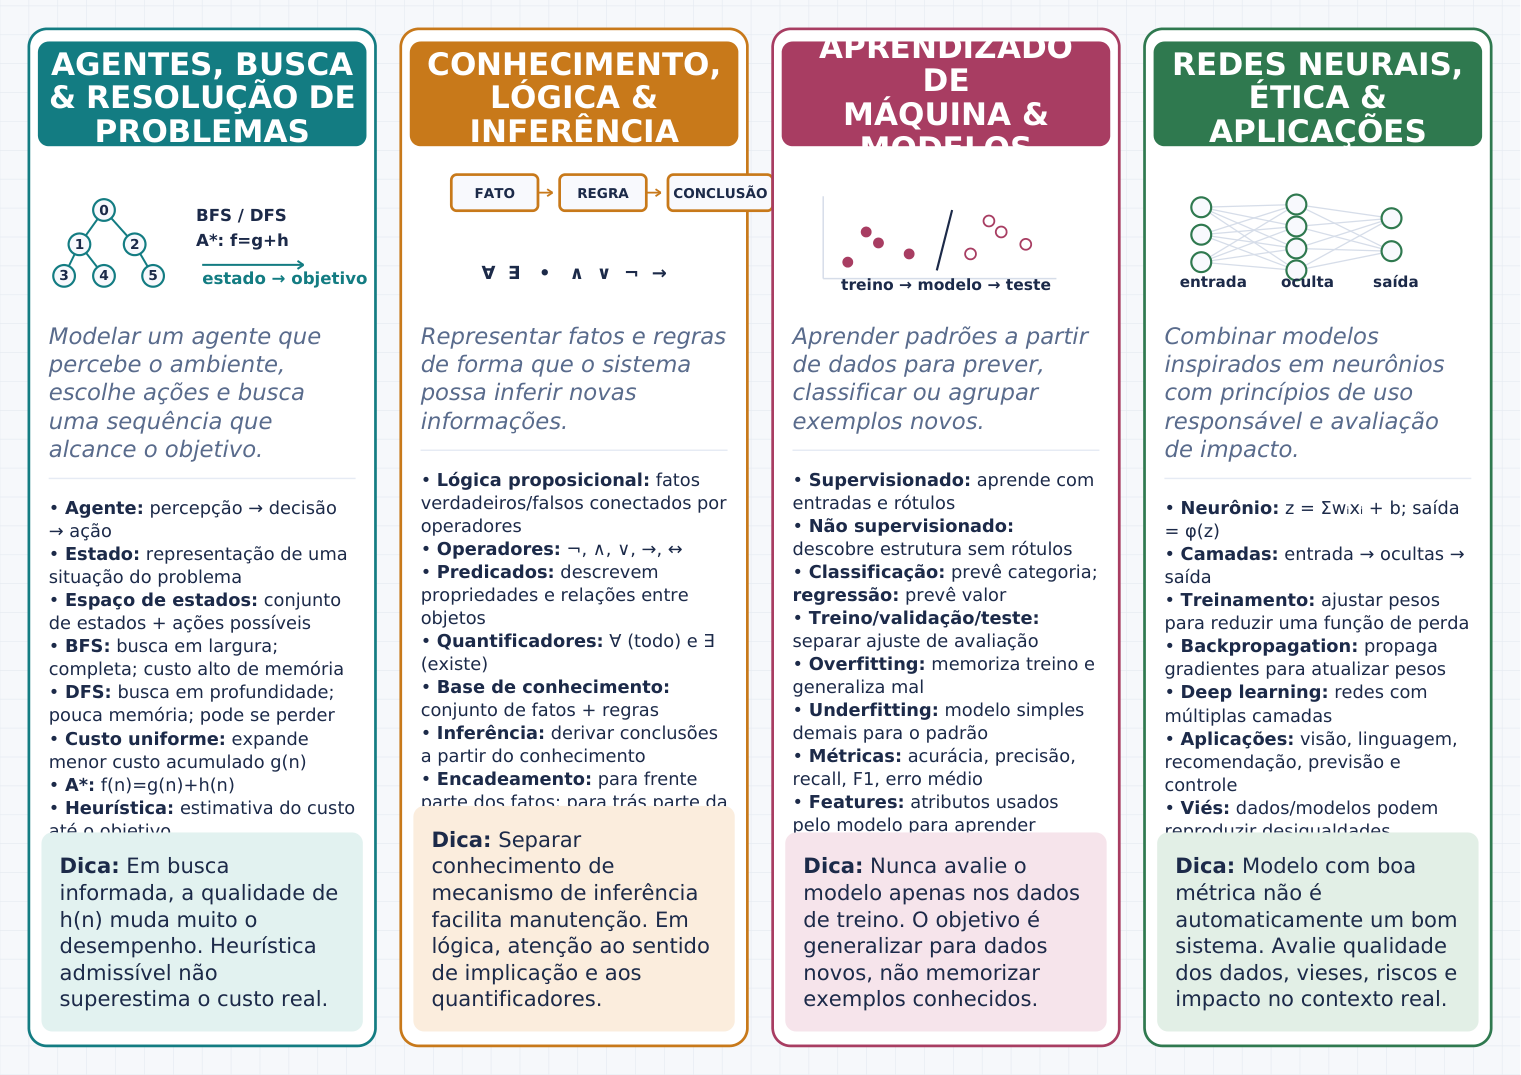

In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path
from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Fundamentos_Inteligencia_Artificial.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR/'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR/'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR/'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily('DVCond', normal='DVCond', bold='DVCond-Bold', italic='DVCond-Oblique', boldItalic='DVCond-Bold')

BG=HexColor('#F6F8FB'); GRID=HexColor('#E6EBF3'); INK=HexColor('#1C2B4A'); MUTED=HexColor('#5A6B8C'); WHITE=HexColor('#FFFFFF'); LINE=HexColor('#E7ECF4'); AXIS=HexColor('#D7DEEA')
TEAL,TEAL_T=HexColor('#147D82'),HexColor('#E3F2F1')
AMBER,AMBER_T=HexColor('#C97A1A'),HexColor('#FBEDDD')
BERRY,BERRY_T=HexColor('#A83E63'),HexColor('#F6E4EB')
GREEN,GREEN_T=HexColor('#2F7A4F'),HexColor('#E2F0E7')

CARDS=[
    {'title':'AGENTES, BUSCA<br/>&amp; RESOLUÇÃO DE PROBLEMAS','color':TEAL,'tint':TEAL_T,'kind':'busca','idea':'Modelar um agente que percebe o ambiente, escolhe ações e busca uma sequência que alcance o objetivo.','formulas':[
        '<b>Agente:</b> percepção → decisão → ação',
        '<b>Estado:</b> representação de uma situação do problema',
        '<b>Espaço de estados:</b> conjunto de estados + ações possíveis',
        '<b>BFS:</b> busca em largura; completa; custo alto de memória',
        '<b>DFS:</b> busca em profundidade; pouca memória; pode se perder',
        '<b>Custo uniforme:</b> expande menor custo acumulado g(n)',
        '<b>A*:</b> f(n)=g(n)+h(n)',
        '<b>Heurística:</b> estimativa do custo até o objetivo',
    ],'tip':'Em busca informada, a qualidade de h(n) muda muito o desempenho. Heurística admissível não superestima o custo real.'},

    {'title':'CONHECIMENTO,<br/>LÓGICA &amp; INFERÊNCIA','color':AMBER,'tint':AMBER_T,'kind':'logica','idea':'Representar fatos e regras de forma que o sistema possa inferir novas informações.','formulas':[
        '<b>Lógica proposicional:</b> fatos verdadeiros/falsos conectados por operadores',
        '<b>Operadores:</b> ¬, ∧, ∨, →, ↔',
        '<b>Predicados:</b> descrevem propriedades e relações entre objetos',
        '<b>Quantificadores:</b> ∀ (todo) e ∃ (existe)',
        '<b>Base de conhecimento:</b> conjunto de fatos + regras',
        '<b>Inferência:</b> derivar conclusões a partir do conhecimento',
        '<b>Encadeamento:</b> para frente parte dos fatos; para trás parte da meta',
        '<b>Ontologia:</b> conceitos, relações e restrições de um domínio',
    ],'tip':'Separar conhecimento de mecanismo de inferência facilita manutenção. Em lógica, atenção ao sentido de implicação e aos quantificadores.'},

    {'title':'APRENDIZADO DE<br/>MÁQUINA &amp; MODELOS','color':BERRY,'tint':BERRY_T,'kind':'ml','idea':'Aprender padrões a partir de dados para prever, classificar ou agrupar exemplos novos.','formulas':[
        '<b>Supervisionado:</b> aprende com entradas e rótulos',
        '<b>Não supervisionado:</b> descobre estrutura sem rótulos',
        '<b>Classificação:</b> prevê categoria; <b>regressão:</b> prevê valor',
        '<b>Treino/validação/teste:</b> separar ajuste de avaliação',
        '<b>Overfitting:</b> memoriza treino e generaliza mal',
        '<b>Underfitting:</b> modelo simples demais para o padrão',
        '<b>Métricas:</b> acurácia, precisão, recall, F1, erro médio',
        '<b>Features:</b> atributos usados pelo modelo para aprender',
    ],'tip':'Nunca avalie o modelo apenas nos dados de treino. O objetivo é generalizar para dados novos, não memorizar exemplos conhecidos.'},

    {'title':'REDES NEURAIS,<br/>ÉTICA &amp; APLICAÇÕES','color':GREEN,'tint':GREEN_T,'kind':'neural','idea':'Combinar modelos inspirados em neurônios com princípios de uso responsável e avaliação de impacto.','formulas':[
        '<b>Neurônio:</b> z = Σwᵢxᵢ + b; saída = φ(z)',
        '<b>Camadas:</b> entrada → ocultas → saída',
        '<b>Treinamento:</b> ajustar pesos para reduzir uma função de perda',
        '<b>Backpropagation:</b> propaga gradientes para atualizar pesos',
        '<b>Deep learning:</b> redes com múltiplas camadas',
        '<b>Aplicações:</b> visão, linguagem, recomendação, previsão e controle',
        '<b>Viés:</b> dados/modelos podem reproduzir desigualdades',
        '<b>Responsabilidade:</b> transparência, privacidade, segurança e supervisão',
    ],'tip':'Modelo com boa métrica não é automaticamente um bom sistema. Avalie qualidade dos dados, vieses, riscos e impacto no contexto real.'},
]

CARD_TOP=PAGE_H-16; CARD_BOTTOM=16; CARD_H=CARD_TOP-CARD_BOTTOM; GAP=14; CARD_W=(PAGE_W-2*MARGIN-3*GAP)/4
STYLE_TITLE=ParagraphStyle('title',fontName='DVCond-Bold',fontSize=17.2,leading=18.6,textColor=WHITE,alignment=1)
STYLE_IDEA=ParagraphStyle('idea',fontName='DVCond-Oblique',fontSize=12.6,leading=15.6,textColor=MUTED)
STYLE_TIP=ParagraphStyle('tip',fontName='DVCond',fontSize=11.7,leading=14.7,textColor=INK)

def arrow(c,x1,y1,x2,y2,color,width=1.1,head=4):
    c.setStrokeColor(color); c.setFillColor(color); c.setLineWidth(width); c.line(x1,y1,x2,y2)
    a=math.atan2(y2-y1,x2-x1)
    for d in (2.55,-2.55): c.line(x2,y2,x2+head*math.cos(a+d),y2+head*math.sin(a+d))

def node(c,x,y,r,color,label=None):
    c.setStrokeColor(color); c.setFillColor(HexColor('#F8FAFD')); c.setLineWidth(1.2); c.circle(x,y,r,stroke=1,fill=1)
    if label:
        c.setFillColor(INK); c.setFont('DVCond-Bold',7.6); c.drawCentredString(x,y-2.5,label)

def diagram_busca(c,ox,oy,dw,dh,color):
    pts=[(ox+dw*.18,oy+dh*.68),(ox+dw*.10,oy+dh*.43),(ox+dw*.28,oy+dh*.43),(ox+dw*.05,oy+dh*.20),(ox+dw*.18,oy+dh*.20),(ox+dw*.34,oy+dh*.20)]
    edges=[(0,1),(0,2),(1,3),(1,4),(2,5)]
    c.setStrokeColor(color); c.setLineWidth(1.1)
    for a,b in edges: c.line(*pts[a],*pts[b])
    for i,(x,y) in enumerate(pts): node(c,x,y,6,color,str(i))
    c.setFillColor(INK); c.setFont('DVCond-Bold',9.2); c.drawString(ox+dw*.48,oy+dh*.60,'BFS / DFS')
    c.drawString(ox+dw*.48,oy+dh*.42,'A*: f=g+h')
    arrow(c,ox+dw*.50,oy+dh*.28,ox+dw*.83,oy+dh*.28,color,1.1,4)
    c.drawString(ox+dw*.50,oy+dh*.14,'estado → objetivo')

def diagram_logica(c,ox,oy,dw,dh,color):
    x=ox+dw*.10; y=oy+dh*.28
    boxes=[('FATO',x,y+30),('REGRA',x+60,y+30),('CONCLUSÃO',x+120,y+30)]
    for lab,bx,by in boxes:
        c.setStrokeColor(color); c.setFillColor(HexColor('#F8FAFD')); c.roundRect(bx,by,48 if lab!='CONCLUSÃO' else 58,20,3,fill=1,stroke=1)
        c.setFillColor(INK); c.setFont('DVCond-Bold',7.5); c.drawCentredString(bx+(24 if lab!='CONCLUSÃO' else 29),by+7,lab)
    arrow(c,x+48,y+40,x+56,y+40,color,1.0,3.5); arrow(c,x+108,y+40,x+116,y+40,color,1.0,3.5)
    c.setFillColor(INK); c.setFont('DVCond-Bold',10); c.drawCentredString(ox+dw*.5,oy+dh*.18,'∀  ∃   •   ∧  ∨  ¬  →')

def diagram_ml(c,ox,oy,dw,dh,color):
    # scatter + separating line
    c.setStrokeColor(AXIS); c.setLineWidth(.8); x0=ox+dw*.10; y0=oy+dh*.18; c.line(x0,y0,x0+dw*.76,y0); c.line(x0,y0,x0,y0+dh*.60)
    pts1=[(.18,.30),(.28,.44),(.38,.36),(.24,.52)]; pts2=[(.58,.36),(.68,.52),(.76,.43),(.64,.60)]
    c.setFillColor(color)
    for px,py in pts1: c.circle(ox+dw*px,oy+dh*py,3,stroke=0,fill=1)
    c.setStrokeColor(color); c.setLineWidth(1.0)
    for px,py in pts2: c.circle(ox+dw*px,oy+dh*py,3,stroke=1,fill=0)
    c.setStrokeColor(INK); c.setLineWidth(1.2); c.line(ox+dw*.47,oy+dh*.24,ox+dw*.52,oy+dh*.68)
    c.setFillColor(INK); c.setFont('DVCond-Bold',8.6); c.drawCentredString(ox+dw*.50,oy+dh*.10,'treino → modelo → teste')

def diagram_neural(c,ox,oy,dw,dh,color):
    layers=[[(ox+dw*.12,oy+dh*y) for y in (.30,.50,.70)],[(ox+dw*.43,oy+dh*y) for y in (.24,.40,.56,.72)],[(ox+dw*.74,oy+dh*y) for y in (.38,.62)]]
    c.setStrokeColor(AXIS); c.setLineWidth(.7)
    for a in layers[0]:
        for b in layers[1]: c.line(a[0],a[1],b[0],b[1])
    for a in layers[1]:
        for b in layers[2]: c.line(a[0],a[1],b[0],b[1])
    for layer in layers:
        for x,y in layer: node(c,x,y,5.5,color)
    c.setFillColor(INK); c.setFont('DVCond-Bold',8.4); c.drawString(ox+dw*.05,oy+dh*.12,'entrada'); c.drawString(ox+dw*.38,oy+dh*.12,'oculta'); c.drawString(ox+dw*.68,oy+dh*.12,'saída')

DIAGRAMS={'busca':diagram_busca,'logica':diagram_logica,'ml':diagram_ml,'neural':diagram_neural}

def draw_card(c,card,cx):
    color,tint=card['color'],card['tint']
    c.setFillColor(WHITE); c.setStrokeColor(color); c.setLineWidth(1.5); c.roundRect(cx,CARD_BOTTOM,CARD_W,CARD_H,10,fill=1,stroke=1)
    header_h=58; header_y=CARD_TOP-7-header_h; c.setFillColor(color); c.roundRect(cx+5,header_y,CARD_W-10,header_h,6,fill=1,stroke=0)
    p=Paragraph(card['title'],STYLE_TITLE); _,ph=p.wrapOn(c,CARD_W-22,header_h-6); p.drawOn(c,cx+11,header_y+(header_h-ph)/2)
    cursor=header_y-11; dh=76; dy=cursor-dh; DIAGRAMS[card['kind']](c,cx+11,dy,CARD_W-22,dh,color); cursor=dy-10
    p=Paragraph(card['idea'],STYLE_IDEA); _,ph=p.wrapOn(c,CARD_W-22,70); p.drawOn(c,cx+11,cursor-ph); cursor-=ph+9
    c.setStrokeColor(LINE); c.setLineWidth(.8); c.line(cx+11,cursor,cx+CARD_W-11,cursor); cursor-=10
    tip_y=CARD_BOTTOM+8; tip=Paragraph('<b>Dica:</b> '+card['tip'],STYLE_TIP); _,tip_txt_h=tip.wrapOn(c,CARD_W-34,130); tip_h=max(72,tip_txt_h+22); tip_top=tip_y+tip_h
    html='<br/>'.join('• '+x for x in card['formulas']); avail=cursor-tip_top-10; fs=10.75; lead=13.65
    while True:
        st=ParagraphStyle('body_'+card['kind'],fontName='DVCond',fontSize=fs,leading=lead,textColor=INK)
        body=Paragraph(html,st); _,bh=body.wrapOn(c,CARD_W-22,470)
        if bh<=avail or fs<=9.95: break
        fs-=.1; lead-=.1
    body.drawOn(c,cx+11,cursor-bh)
    c.setFillColor(tint); c.roundRect(cx+7,tip_y,CARD_W-14,tip_h,6,fill=1,stroke=0); tip.drawOn(c,cx+17,tip_y+(tip_h-tip_txt_h)/2)

c=canvas.Canvas(str(OUT),pagesize=landscape(A4)); c.setTitle('Fundamentos da Inteligência Artificial - Cheat Sheet OneNote'); c.setAuthor('OpenAI')
c.setFillColor(BG); c.rect(0,0,PAGE_W,PAGE_H,fill=1,stroke=0); c.setStrokeColor(GRID); c.setLineWidth(.35)
step=16; x=0
while x<PAGE_W: c.line(x,0,x,PAGE_H); x+=step
y=0
while y<PAGE_H: c.line(0,y,PAGE_W,y); y+=step
x=MARGIN
for card in CARDS: draw_card(c,card,x); x+=CARD_W+GAP
c.save(); print(OUT)


# ===== renderização do PDF gerado =====
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Fundamentos_Inteligencia_Artificial.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF acima).

### 🟢 AGENTES, BUSCA & RESOLUÇÃO DE PROBLEMAS

**Ideia:** Modelar um agente que percebe o ambiente, escolhe ações e busca uma sequência que alcance o objetivo.

- Agente: percepção → decisão → ação
- Estado: representação de uma situação do problema
- Espaço de estados: conjunto de estados + ações possíveis
- BFS: busca em largura; completa; custo alto de memória
- DFS: busca em profundidade; pouca memória; pode se perder
- Custo uniforme: expande menor custo acumulado g(n)
- A*: f(n)=g(n)+h(n)
- Heurística: estimativa do custo até o objetivo

> 💡 **Dica:** Em busca informada, a qualidade de h(n) muda muito o desempenho. Heurística admissível não superestima o custo real.

### 🟢 CONHECIMENTO, LÓGICA & INFERÊNCIA

**Ideia:** Representar fatos e regras de forma que o sistema possa inferir novas informações.

- Lógica proposicional: fatos verdadeiros/falsos conectados por operadores
- Operadores: ¬, ∧, ∨, →, ↔
- Predicados: descrevem propriedades e relações entre objetos
- Quantificadores: ∀ (todo) e ∃ (existe)
- Base de conhecimento: conjunto de fatos + regras
- Inferência: derivar conclusões a partir do conhecimento
- Encadeamento: para frente parte dos fatos; para trás parte da meta
- Ontologia: conceitos, relações e restrições de um domínio

> 💡 **Dica:** Separar conhecimento de mecanismo de inferência facilita manutenção. Em lógica, atenção ao sentido de implicação e aos quantificadores.

### 🟢 APRENDIZADO DE MÁQUINA & MODELOS

**Ideia:** Aprender padrões a partir de dados para prever, classificar ou agrupar exemplos novos.

- Supervisionado: aprende com entradas e rótulos
- Não supervisionado: descobre estrutura sem rótulos
- Classificação: prevê categoria; regressão: prevê valor
- Treino/validação/teste: separar ajuste de avaliação
- Overfitting: memoriza treino e generaliza mal
- Underfitting: modelo simples demais para o padrão
- Métricas: acurácia, precisão, recall, F1, erro médio
- Features: atributos usados pelo modelo para aprender

> 💡 **Dica:** Nunca avalie o modelo apenas nos dados de treino. O objetivo é generalizar para dados novos, não memorizar exemplos conhecidos.

### 🟢 REDES NEURAIS, ÉTICA & APLICAÇÕES

**Ideia:** Combinar modelos inspirados em neurônios com princípios de uso responsável e avaliação de impacto.

- Neurônio: z = Σwᵢxᵢ + b; saída = φ(z)
- Camadas: entrada → ocultas → saída
- Treinamento: ajustar pesos para reduzir uma função de perda
- Backpropagation: propaga gradientes para atualizar pesos
- Deep learning: redes com múltiplas camadas
- Aplicações: visão, linguagem, recomendação, previsão e controle
- Viés: dados/modelos podem reproduzir desigualdades
- Responsabilidade: transparência, privacidade, segurança e supervisão

> 💡 **Dica:** Modelo com boa métrica não é automaticamente um bom sistema. Avalie qualidade dos dados, vieses, riscos e impacto no contexto real.


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


1) BUSCA EM GRAFO - BFS e DFS
   BFS A->F: ['A', 'C', 'F']
   DFS A->F: ['A', 'C', 'F']

2) PERCEPTRON: porta AND
   pesos: [0.2 0.1] | bias: -0.20 | previsoes: [0, 0, 0, 1]

3) REGRESSAO LINEAR (gradiente descendente)
   modelo ajustado: y = 2.51x + 3.01 (real: y = 2.50x + 3.00)


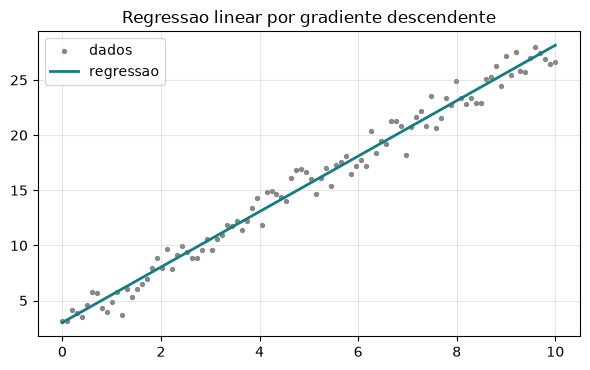


4) kNN (k vizinhos mais proximos) - classificacao
   ponto [2, 1] -> classe 0
   ponto [5, 6] -> classe 1
   ponto [3, 3] -> classe 0

OK - IA classica implementada do zero.


In [2]:

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

print("=" * 60)
print("1) BUSCA EM GRAFO - BFS e DFS")
grafo = {"A": ["B", "C"], "B": ["D", "E"], "C": ["F"], "D": [], "E": ["F"], "F": []}
def busca(g, inicio, alvo, modo="bfs"):
    fila = deque([inicio]); vis = {inicio}; pai = {inicio: None}
    while fila:
        v = fila.popleft() if modo == "bfs" else fila.pop()
        if v == alvo: break
        for nb in g[v]:
            if nb not in vis:
                vis.add(nb); pai[nb] = v
                fila.append(nb) if modo == "bfs" else fila.append(nb)
    caminho = []
    if alvo in pai:
        x = alvo
        while x is not None:
            caminho.append(x); x = pai[x]
        caminho.reverse()
    return caminho
print(f"   BFS A->F: {busca(grafo, 'A', 'F', 'bfs')}")
print(f"   DFS A->F: {busca(grafo, 'A', 'F', 'dfs')}")

print("\n2) PERCEPTRON: porta AND")
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([0, 0, 0, 1])
w = np.zeros(2); b = 0.0; taxa = 0.1
for epoca in range(50):
    for xi, yi in zip(X, y):
        saida = 1 if (xi@w + b) >= 0 else 0
        erro = yi - saida
        w += taxa*erro*xi; b += taxa*erro
testes = [(xi, 1 if (xi@w + b) >= 0 else 0) for xi in X]
print(f"   pesos: {w.round(2)} | bias: {b:.2f} | previsoes: {[t[1] for t in testes]}")

print("\n3) REGRESSAO LINEAR (gradiente descendente)")
x = np.linspace(0, 10, 100)
y_real = 2.5*x + 3 + np.random.default_rng(0).normal(0, 1, 100)
a, b2, lr = 0.0, 0.0, 0.01
for _ in range(2000):
    pred = a*x + b2
    da = (2/len(x))*(x*(pred - y_real)).sum()
    db = (2/len(x))*(pred - y_real).sum()
    a -= lr*da; b2 -= lr*db
print(f"   modelo ajustado: y = {a:.2f}x + {b2:.2f} (real: y = 2.50x + 3.00)")

xx = np.linspace(0, 10, 20)
plt.figure(figsize=(6, 3.8))
plt.scatter(x, y_real, s=8, color="#888", label="dados")
plt.plot(xx, a*xx + b2, color="#147D82", lw=2, label="regressao")
plt.title("Regressao linear por gradiente descendente")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

print("\n4) kNN (k vizinhos mais proximos) - classificacao")
from collections import Counter
dados = np.array([[1,1],[1,2],[2,2],[5,5],[6,5],[6,6]])
rotulos = np.array([0,0,0,1,1,1])
def knn(ponto, k=3):
    dist = np.sqrt(((dados - ponto)**2).sum(axis=1))
    viz = rotulos[np.argsort(dist)[:k]]
    return Counter(viz).most_common(1)[0][0]
for p in ([2,1], [5,6], [3,3]):
    print(f"   ponto {p} -> classe {knn(np.array(p, float))}")
print("\nOK - IA classica implementada do zero.")


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
